# NLP03 Project_BERT

## 0. 사전 작업

### 0-1. 환경 체크 및 필수 라이브러리 설치

In [1]:
import torch
print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

PyTorch 버전: 2.6.0+cu124
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060


In [2]:
import torch
import sentencepiece
import tqdm

print(torch.__version__)
print(torch.cuda.is_available())
print(sentencepiece.__version__)

2.6.0+cu124
True
0.2.1


In [3]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [4]:
import torchsummary

### 0-2. imports 및 기본설정

In [5]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import copy

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm import tqdm

# 경로 설정
data_dir = 'data'
model_dir = 'models'
work_dir = 'work'

# 랜덤 시드 고정 (재현성 확보)
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# 버전 확인
print("torch version:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

torch version: 2.6.0+cu124
CUDA 사용 가능: True


In [47]:
# 설치된 한국어 폰트 목록 확인
import matplotlib.font_manager as fm

fonts = [f.name for f in fm.fontManager.ttflist if 'Malgun' in f.name or 'Nanum' in f.name or 'Gothic' in f.name]
print(fonts)

['HYGothic-Medium', 'Franklin Gothic Demi Cond', 'NanumGothic', 'Copperplate Gothic Light', 'AppleSDGothicNeoEB00', 'Nanum DdarEGeEomMaGa', 'NanumMyeongjo', 'Yu Gothic', 'Copperplate Gothic Bold', 'AppleSDGothicNeoH00', 'Nanum HarABeoJiEuiNaNum', 'NanumMyeongjo', 'Century Gothic', 'Franklin Gothic Heavy', 'Malgun Gothic', 'NanumMyeongjoOTF', 'Malgun Gothic', 'Hancom Gothic', 'BankGothic Md BT', 'AppleSDGothicNeoL00', 'Franklin Gothic Demi', 'Hancom Gothic', 'NanumMyeongjoOTF', 'Yu Gothic', 'Jalnan Gothic', 'Franklin Gothic Book', 'Franklin Gothic Demi', 'Showcard Gothic', 'Franklin Gothic Medium Cond', 'Century Gothic', 'AppleSDGothicNeoB00', 'Franklin Gothic Book', 'Franklin Gothic Heavy', 'Century Gothic', 'GothicI', 'Yu Gothic', 'AppleSDGothicNeoM00', 'Franklin Gothic Medium', 'BankGothic Lt BT', 'GothicE', 'NanumMyeongjoOTF', 'Yu Gothic', 'GothicG', 'Malgun Gothic', 'NanumMyeongjo', 'HYGothic-Extra', 'Franklin Gothic Medium', 'MS Gothic', 'Century Gothic']


### 0-3. 데이터 확인

In [6]:
corpus_file = os.path.join(data_dir, 'kowiki.txt')

# 파일 존재 여부 확인
print("파일 존재:", os.path.exists(corpus_file))

# 첫 5줄 확인
with open(corpus_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"line {i}:", line.strip())

파일 존재: True
line 0: 지미 카터
line 1: 제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.
line 2: 지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.
line 3: 1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임했다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.
line 4: 1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.


## 1. 토크나이저 학습 (SentencePiece)

- 서브워드 사전 학습: 한국어 위키 코퍼스를 바탕으로 BPE(Byte-pair Encoding) 알고리즘을 적용해 효율적인 단어 사전을 만듭니다.
- 어휘 규모 설정: 모델 최적화를 위해 8,000개의 기본 어휘를 추출합니다.
- 필수 특수 토큰 추가: BERT 모델 구동에 꼭 필요한 7개의 특수 토큰([CLS], [SEP], [MASK] 등)을 어휘 사전에 통합합니다.
- 모델 파일 생성: 텍스트를 숫자로 변환해 줄 토크나이저 모델(.model)과 어휘 리스트(.vocab) 파일을 최종적으로 생성합니다.

### 1-1. SentencePiece 모델 학습

In [7]:
corpus_file = os.path.join(data_dir, 'kowiki.txt')
prefix = os.path.join(model_dir, 'ko_8000')
vocab_size = 8000

# SentencePiece 모델 학습
# BERT에 필요한 특수 토큰 포함: [PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK]
spm.SentencePieceTrainer.train(
    f'--input={corpus_file} '
    f'--model_prefix={prefix} '
    f'--vocab_size={vocab_size + 7} '  # 특수 토큰 7개 포함
    f'--model_type=bpe '
    f'--max_sentence_length=999999 '
    f'--pad_id=0 --pad_piece=[PAD] '
    f'--unk_id=1 --unk_piece=[UNK] '
    f'--bos_id=2 --bos_piece=[BOS] '
    f'--eos_id=3 --eos_piece=[EOS] '
    f'--user_defined_symbols=[SEP],[CLS],[MASK]'
)

print("모델 파일 생성 확인:")
print(os.path.exists(os.path.join(model_dir, 'ko_8000.model')))
print(os.path.exists(os.path.join(model_dir, 'ko_8000.vocab')))

모델 파일 생성 확인:
True
True


### 1-2. Vocab 로딩 및 확인

In [8]:
# vocab 로딩
vocab = spm.SentencePieceProcessor()
vocab.load(os.path.join(model_dir, 'ko_8000.model'))

# 특수 토큰 7개 제외한 나머지 토큰 확인
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print("vocab 전체 크기:", len(vocab))
print("vocab 일부 확인:", vocab_list[:10])

vocab 전체 크기: 8007
vocab 일부 확인: ['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다']


### 1-3. 토크나이징 테스트

In [9]:
# [CLS], tokens_a, [SEP], tokens_b, [SEP] 형태로 토큰 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
string_b = "첫 번에 삼십 전 둘째 번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"

tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print("토크나이징 결과:", tokens_org)
print("토큰 수:", len(tokens_org))

토크나이징 결과: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]']
토큰 수: 53


## 2. 데이터 전처리

- 단어 단위 그룹화: 서브워드가 조각나서 정답을 너무 쉽게 맞추는 것을 방지하기 위해, 띄어쓰기 기반의 단어 단위로 마스킹 후보를 묶습니다.
- 15% 마스킹 전략: 전체 토큰의 15%를 무작위로 선정하여 학습 데이터로 활용합니다.
- 80/10/10 변형 규칙: 선정된 토큰은 [MASK] 교체(80%), 기존 유지(10%), 무작위 단어 교체(10%) 비율로 가공하여 모델의 추론 능력을 극대화합니다.
- 학습 정보 반환: 최종적으로 마스킹된 문장과 함께 정답을 맞추기 위한 마스크 위치(Index) 및 실제 정답(Label)을 추출합니다.

### 2-1. Mask 생성

#### creat_pretain_mask() 구현

In [10]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for i, token in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        # 서브워드 시작(▁)이 아니면 이전 단어에 합치기
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 index 순서를 섞음
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:  # 현재 mask된 개수가 15%를 넘으면 중지
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
            continue
        dice = random.random()  # 0과 1 사이의 확률 값

        for index in index_set:
            masked_token = None
            if dice < 0.8:    # 80% → [MASK]로 교체
                masked_token = "[MASK]"
            elif dice < 0.9:  # 10% → 원래 토큰 유지
                masked_token = tokens[index]
            else:             # 10% → 랜덤 토큰으로 교체
                masked_token = random.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

#### 함수 테스트

In [11]:
# 테스트 (tokens_org를 수정하지 않기 위해 deepcopy 사용)
tokens = copy.deepcopy(tokens_org)
mask_cnt = int((len(tokens_org) - 3) * 0.15)  # [CLS], [SEP], [SEP] 3개 제외

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("원본 tokens:", tokens_org)
print()
print("masked tokens:", tokens)
print()
print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

원본 tokens: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]']

masked tokens: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '[MASK]', '[MASK]', '[MASK]', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]']

mask_idx   : [18, 19, 20, 24, 36, 37, 38]
mask_label : ['▁손', '님', '이', '▁첫', '▁오', '랜', '만에']


### 2-2. NSP pair 생성

#### trim_tokens() 구현

In [12]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        # 긴 쪽에서 제거 (A가 길면 앞에서, B가 길면 뒤에서)
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

#### create_pretrain_instances() 구현

In [13]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # [CLS], [SEP], [SEP] 3개 제외
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # tokens_a 분할 지점 랜덤 선택
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% 확률로 swap (NotNext)
            if random.random() < 0.5:
                is_next = 0  # False
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1  # True

            # max_seq 초과 시 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # tokens & segment 생성
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # mask 생성
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens,
                int((len(tokens) - 3) * mask_prob),
                vocab_list
            )

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

#### 함수테스트

In [14]:
# 테스트용 문자열
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에"""

# 줄 단위로 토크나이즈
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]

n_test_seq = 64
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

for instance in instances:
    print(instance)
    print()

{'tokens': ['[CLS]', '[MASK]', '[MASK]', '[MASK]', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '[MASK]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '리스', '▁오', '십', '[MASK]', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [1, 2, 3, 10, 11, 20, 23], 'mask_label': ['▁그', '날', '은', '▁많', '아', '▁번', '▁전']}



### 2-3. 데이터셋 완성

#### make_pretrain_data() 구현

In [15]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    pretrain 데이터 생성
    """
    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # line count 확인
    line_cnt = 0
    with open(in_file, 'r', encoding='utf-8') as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, 'r', encoding='utf-8') as in_f:
        with open(out_file, 'w', encoding='utf-8') as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # 빈 줄이면 새로운 단락
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                    doc = []
                else:  # 빈 줄이 아니면 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)

            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)

#### 전체 코퍼스에 적용

In [16]:
pretrain_json_path = os.path.join(work_dir, 'bert_pre_train.json')

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

# 라인 수 확인
total = 0
with open(pretrain_json_path, 'r', encoding='utf-8') as f:
    for line in f:
        total += 1
print("생성된 instance 수:", total)

100%|██████████| 3957761/3957761 [02:38<00:00, 24961.16it/s]


생성된 instance 수: 918173


#### load_pre_train_data() 함수

In [17]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    # np.memmap으로 메모리 효율적으로 데이터 처리
    enc_tokens = np.memmap(
        filename='enc_tokens.memmap', mode='w+',
        dtype=np.int32, shape=(total, n_seq)
    )
    segments = np.memmap(
        filename='segments.memmap', mode='w+',
        dtype=np.int32, shape=(total, n_seq)
    )
    labels_nsp = np.memmap(
        filename='labels_nsp.memmap', mode='w+',
        dtype=np.int32, shape=(total,)
    )
    labels_mlm = np.memmap(
        filename='labels_mlm.memmap', mode='w+',
        dtype=np.int32, shape=(total, n_seq)
    )

    with open(filename, 'r', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                break
            data = json.loads(line)

            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))  # padding

            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))  # padding

            # nsp label
            label_nsp = data["is_next"]

            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=int)
            mask_label = np.array(
                [vocab.piece_to_id(p) for p in data["mask_label"]],
                dtype=int
            )
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

#### 데이터 로딩 테스트

In [18]:
n_seq = 128

# GPU 환경 - 전체 데이터 로딩 (918,173건)
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, pretrain_json_path, n_seq, count=None  # 전체 데이터 사용
)

# 처음과 마지막 확인
print("enc_tokens shape:", pre_train_inputs[0].shape)
print("segments shape:", pre_train_inputs[1].shape)
print("labels_nsp shape:", pre_train_labels[0].shape)
print("labels_mlm shape:", pre_train_labels[1].shape)
print()
print("첫 번째 enc_token:", pre_train_inputs[0][0])
print("첫 번째 segment:", pre_train_inputs[1][0])
print("첫 번째 nsp label:", pre_train_labels[0][0])

100%|██████████| 918173/918173 [01:08<00:00, 13376.94it/s]

enc_tokens shape: (918173, 128)
segments shape: (918173, 128)
labels_nsp shape: (918173,)
labels_mlm shape: (918173, 128)

첫 번째 enc_token: [   5    6 1607 3599 1756 3630   41 3644  830 3624 1135   52 3599   13
  851   87 1502 2247   25 3779 3873 3667 3631 3813 3873 4196 3636 3779
 3601  249 3725 1233   33   52 3599  479 3652 3625  243 2780   14 1510
    6    6    6  166 1697 4290 3873 3703 3683  593    6    6 2213 1928
 3607  813   17 3599  307  587  930  104 4313 4290  613 3638 3718   99
 3878 3656  256 2543  309  337 3735  181 3616 3603  489  376 3599    4
   18 3686  207 3714 3324    6  104 3610 3686 3718  207 3714   37 3417
  416  810 3666 3625    6    6    7 3629  203  241 3602 1114 3724    6
  243   49 3632  796  663 1648 3682 3682 3625  203 3009 3625 3616   16
 3599    4]
첫 번째 segment: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1

## 3. BERT 모델 구현

### 3-1. 유틸리티 함수 및 Config Class

In [19]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros

print("완료")

완료


In [20]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

print("완료")

완료


### 3-2. Embedding 레이어

In [21]:
class SharedEmbedding(nn.Module):
    """
    Weighted Shared Embedding Class
    Token Embedding과 최종 output linear layer의 가중치를 공유
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(
            torch.empty(self.n_vocab, self.d_model)
        )
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """embedding lookup"""
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        """linear 실행 (bs, n_seq, d_model) → (bs, n_seq, n_vocab)"""
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs


class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    Transformer의 sin/cos 방식과 달리 BERT는 위치 정보를 학습으로 습득
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        # 입력 토큰 길이만큼 position index 생성
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("완료")

완료


### 3-3. Attention

In [40]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        attn_score /= math.sqrt(Q.size(-1))
        attn_score = attn_score.masked_fill(attn_mask.bool(), -1e9)  # ← .bool() 추가
        attn_prob = F.softmax(attn_score, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)

        # Scale Dot Product Attention
        self.attention = ScaleDotProductAttention()

        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        # reshape Q, K, V → (batch_size, n_head, n_seq, d_head)
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        # (batch_size, n_seq, n_head, d_head) → (batch_size, n_seq, d_model)
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)

        return attn_out

print("완료")

완료


### 3-4. PositionWiseFeedForward + EncoderLayer

In [41]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        # d_model → d_ff → d_model
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val


class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        # Self Attention + Residual + LayerNorm
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        # FeedForward + Residual + LayerNorm
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("완료")

완료


### 3-5. BERT Class

In [42]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        super(BERT, self).__init__()

        self.i_pad = config.i_pad

        # 3가지 Embedding 레이어
        self.embedding = SharedEmbedding(config)        # Token Embedding
        self.position = PositionEmbedding(config)       # Position Embedding
        self.segment = nn.Embedding(2, config.d_model)  # Segment Embedding
        nn.init.trunc_normal_(self.segment.weight, std=0.02)

        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        # Encoder 레이어 쌓기
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config) for _ in range(config.n_layer)]
        )

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        # pad mask 생성
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        # embedding 생성
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        # Encoder 레이어 통과
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        # CLS 토큰 출력 (NSP용)
        logits_cls = enc_out[:, 0]
        # MLM 출력
        logits_lm = self.embedding(enc_out, mode="linear")

        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding + position embedding + segment embedding
        """
        embed = (
            self.embedding(tokens)    # Token Embedding
            + self.position(tokens)   # Position Embedding
            + self.segment(segments)  # Segment Embedding
        )
        embed = self.norm(embed)
        return embed

print("완료")

완료


### 3-6. PreTrainModel

In [43]:
class PooledOutput(nn.Module):
    """
    NSP task를 위한 CLS 토큰 출력 처리 클래스
    """
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        # tanh 활성화 후 분류
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    """
    BERT Pretrain Model Class
    MLM + NSP 동시 학습
    """
    def __init__(self, config):
        super(PreTrainModel, self).__init__()

        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)  # NSP: 2개 클래스

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        # BERT 통과
        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # NSP 출력
        outputs_nsp = self.pooled_output(logits_cls)

        # MLM 출력
        outputs_mlm = logits_lm

        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

print("완료")

완료


#### 학습된 가중치 다시 로드

In [44]:
pre_train_model = build_model_pre_train(config).to(device)
pre_train_model.load_state_dict(
    torch.load('work/bert_pre_train_epoch_10.pt', map_location=device)
)
pre_train_model.eval()

PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(128, 96)
    )
    (segment): Embedding(2, 96)
    (norm): LayerNorm((96,), eps=0.001, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=96, out_features=96, bias=True)
          (W_K): Linear(in_features=96, out_features=96, bias=True)
          (W_V): Linear(in_features=96, out_features=96, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=96, out_features=96, bias=True)
        )
        (norm1): LayerNorm((96,), eps=0.001, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=96, out_features=256, bias=True)
          (W_2): Linear(in_features=256, out_features=96, bias=True)
          (gelu): GELU(approximate='none')
        )
        (norm2

### 3-7. 모델 config 설정 및 생성 테스트

In [26]:
# mini BERT config (전체 파라미터 약 1M 목표)
config = Config({
    "n_vocab": len(vocab),      # 8007
    "d_model": 128,             # 임베딩 차원
    "n_head": 4,                # attention head 수
    "d_head": 32,               # head 당 차원 (d_model / n_head)
    "d_ff": 512,                # feed forward 차원
    "dropout": 0.1,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,               # encoder 레이어 수
    "n_seq": 128,               # 시퀀스 길이
    "i_pad": 0                  # padding id
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# 모델 생성
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"전체 파라미터 수: {total_params:,}")

사용 디바이스: cuda
전체 파라미터 수: 1,653,376


In [27]:
# 파라미터 수가 높게 나와 config 수정정
config = Config({
    "n_vocab": len(vocab),      # 8007
    "d_model": 64,              # 128 → 64로 축소
    "n_head": 4,                # attention head 수 유지
    "d_head": 16,               # d_model / n_head = 64 / 4
    "d_ff": 256,                # 512 → 256으로 축소
    "dropout": 0.1,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,               # encoder 레이어 수 유지
    "n_seq": 128,               # 시퀀스 길이 유지
    "i_pad": 0                  # padding id
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# 모델 생성
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"전체 파라미터 수: {total_params:,}")

사용 디바이스: cuda
전체 파라미터 수: 675,136


In [28]:
config = Config({
    "n_vocab": len(vocab),      # 8007
    "d_model": 96,              # 유지
    "n_head": 4,                # 유지
    "d_head": 24,               # 유지
    "d_ff": 256,                # 384 → 256으로 축소
    "dropout": 0.1,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,               # 유지
    "n_seq": 128,               # 유지
    "i_pad": 0
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

total_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"전체 파라미터 수: {total_params:,}")

사용 디바이스: cuda
전체 파라미터 수: 1,052,256


## 4. Pretrain

### 4-1. Loss 및 Accuracy 함수

In [29]:
def lm_loss(y_true, y_pred):
    """
    MLM loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),
        y_true.view(-1),
        reduction='none'
    )
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask.view(-1)
    return loss.sum() / mask.sum().clamp(min=1)


def lm_acc(y_true, y_pred):
    """
    MLM accuracy 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("완료")

완료


### 4-2. Learning Rate 스케줄러

In [30]:
class CosineSchedule:
    """
    WarmUp 이후 Cosine 형태로 감소하는 LR 스케줄러
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            # WarmUp 구간: 선형 증가
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            # Cosine 구간: 점진적 감소
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
        return lr

print("완료")

완료


### 4-3. 학습 데이터 준비

In [31]:
# 데이터를 tensor로 변환
pre_train_inputs = [torch.as_tensor(x, device=device) for x in pre_train_inputs]
pre_train_labels = [torch.as_tensor(x, device=device) for x in pre_train_labels]

# TensorDataset 및 DataLoader 생성
batch_size = 64

train_dataset = TensorDataset(
    pre_train_inputs[0],   # enc_tokens
    pre_train_inputs[1],   # segments
    pre_train_labels[0],   # labels_nsp
    pre_train_labels[1]    # labels_mlm
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("전체 데이터 수:", len(train_dataset))
print("배치 수:", len(train_dataloader))

전체 데이터 수: 918173
배치 수: 14347


### 4-4. 학습 루프

In [32]:
# 학습 설정
epochs = 10
train_steps = math.ceil(len(train_dataloader)) * epochs
warmup_steps = max(100, train_steps // 10)

# optimizer 및 스케줄러 설정S
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=5e-4
)

# loss 함수 설정
loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()

# 학습 기록
history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

# 학습 루프
for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        # 순전파
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # label 타입 변환
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        # loss 계산
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(
            logits_mlm.view(-1, logits_mlm.shape[-1]),
            labels_mlm_batch.view(-1)
        )

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # 역전파
        total_loss_batch.backward()
        optimizer.step()
        learning_rate_scheduler.step()

        # accuracy 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = lm_acc(labels_mlm_batch, logits_mlm)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 에폭별 평균 기록
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} "
          f"- Loss: {total_loss / len(train_dataloader):.4f} "
          f"- NSP Loss: {history['nsp_loss'][-1]:.4f} "
          f"- MLM Loss: {history['mlm_loss'][-1]:.4f} "
          f"- NSP Acc: {history['nsp_acc'][-1]:.4f} "
          f"- MLM Acc: {history['mlm_acc'][-1]:.4f}")

    # 모델 저장
    torch.save(
        pre_train_model.state_dict(),
        os.path.join(work_dir, f"bert_pre_train_epoch_{epoch+1}.pt")
    )

Epoch 1/10: 100%|██████████| 14347/14347 [08:15<00:00, 28.98it/s]


Epoch 1/10 - Loss: 1.8174 - NSP Loss: 0.4111 - MLM Loss: 1.4064 - NSP Acc: 0.7447 - MLM Acc: 0.0188


Epoch 2/10: 100%|██████████| 14347/14347 [08:18<00:00, 28.79it/s]


Epoch 2/10 - Loss: 1.1445 - NSP Loss: 0.3671 - MLM Loss: 0.7774 - NSP Acc: 0.7642 - MLM Acc: 0.0381


Epoch 3/10: 100%|██████████| 14347/14347 [08:19<00:00, 28.74it/s]


...

Epoch 8/10 - Loss: 0.9067 - NSP Loss: 0.3192 - MLM Loss: 0.5875 - NSP Acc: 0.8045 - MLM Acc: 0.1382


Epoch 9/10: 100%|██████████| 14347/14347 [09:52<00:00, 24.22it/s]


Epoch 9/10 - Loss: 0.8970 - NSP Loss: 0.3119 - MLM Loss: 0.5851 - NSP Acc: 0.8118 - MLM Acc: 0.1398


Epoch 10/10: 100%|██████████| 14347/14347 [08:35<00:00, 27.82it/s]

Epoch 10/10 - Loss: 0.8921 - NSP Loss: 0.3080 - MLM Loss: 0.5841 - NSP Acc: 0.8148 - MLM Acc: 0.1404


### 4-5. 학습 결과 시각화

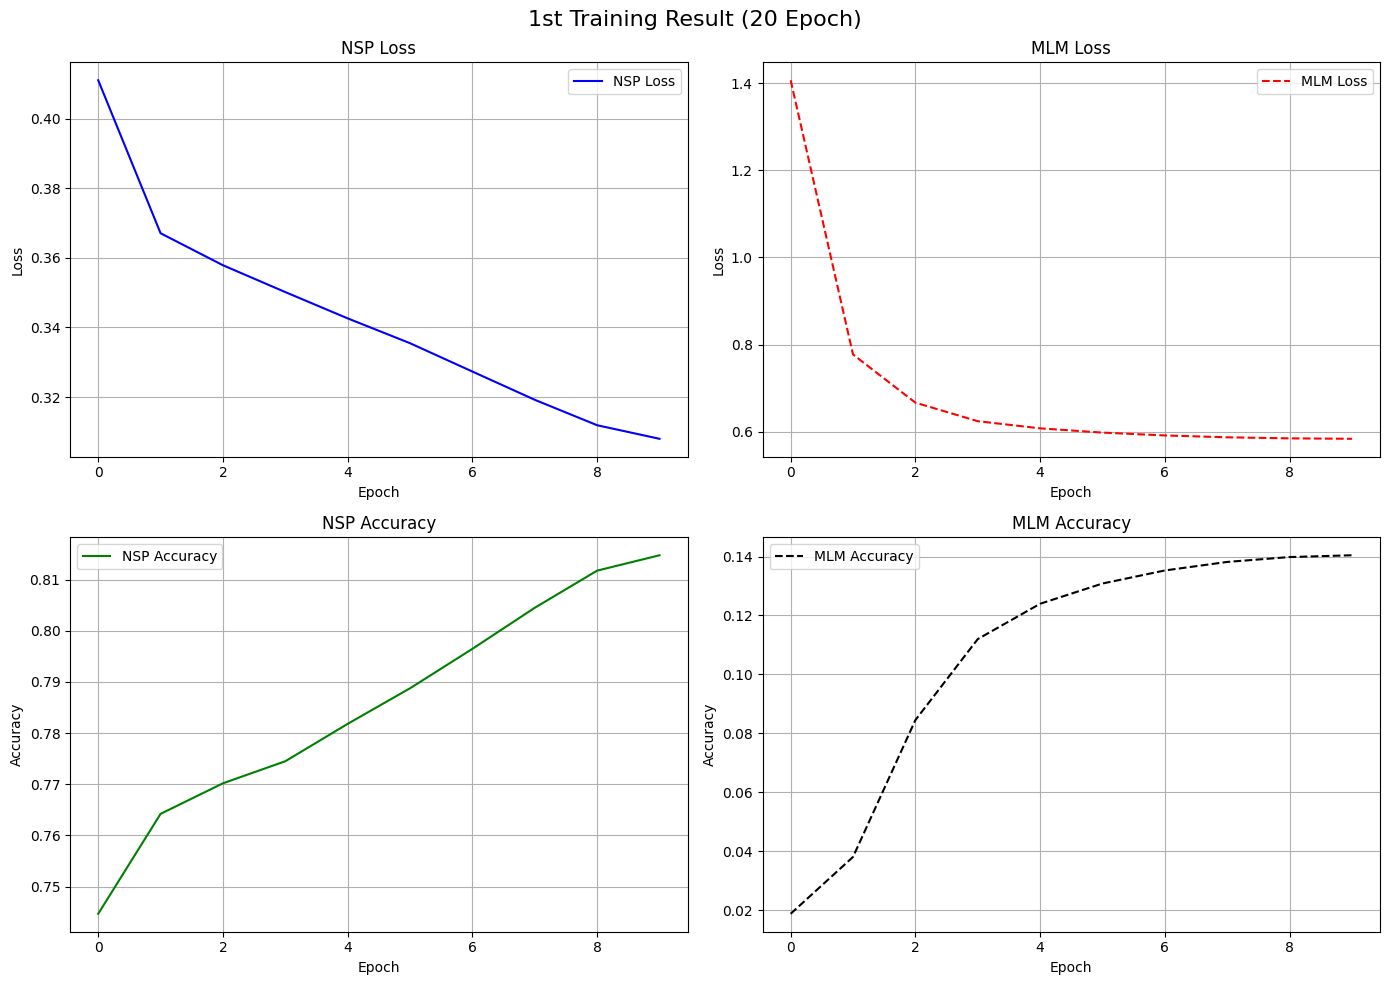

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('1st Training Result (20 Epoch)', fontsize=16)

# NSP Loss
axes[0, 0].plot(history['nsp_loss'], 'b-', label='NSP Loss')
axes[0, 0].set_title('NSP Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# MLM Loss
axes[0, 1].plot(history['mlm_loss'], 'r--', label='MLM Loss')
axes[0, 1].set_title('MLM Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# NSP Accuracy
axes[1, 0].plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
axes[1, 0].set_title('NSP Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# MLM Accuracy
axes[1, 1].plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
axes[1, 1].set_title('MLM Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(work_dir, 'history_1st.png'))
plt.show()

#### 소회

- 퍼실님 曰 : 아직 Accuracy 값들이 수렴을 하지 않는 모습을 보니 학습이 덜 된 모습이다. Epoch를 조금 더 늘려서 진행해보았으면 좋겠다.
- 퍼실님의 조언을 들어 3차 학습 때 Epoch 20으로 진행하였다.

## 5. 모델 분석

### 5-1. Attetion Heatmap

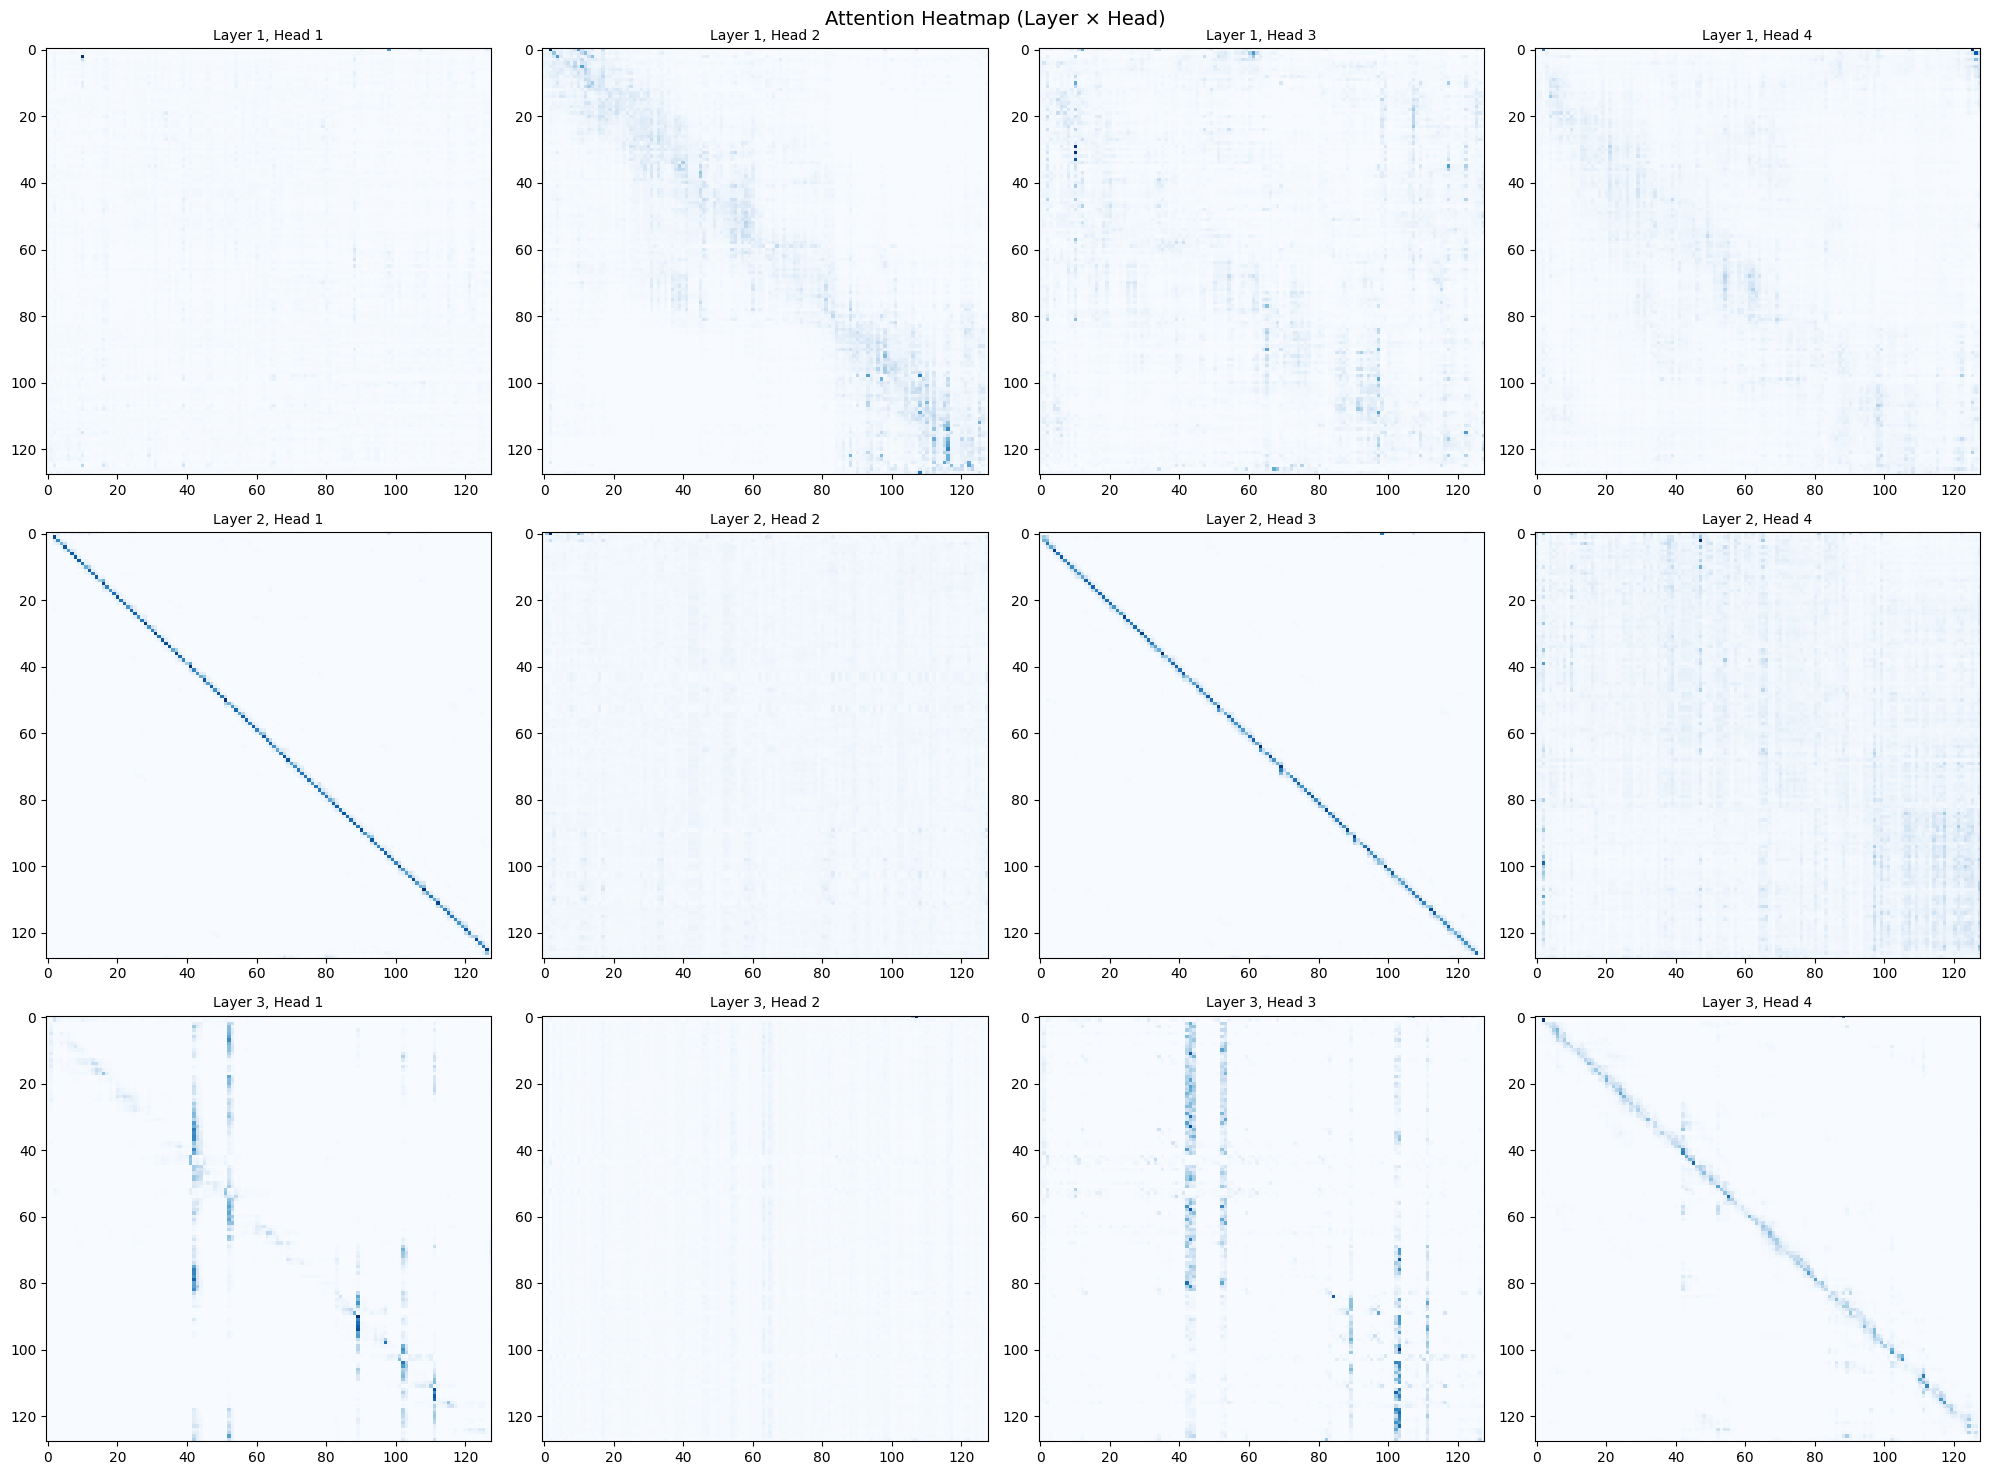

In [45]:
# BERT 클래스의 forward에서 attention weights를 반환하도록 수정 필요
# 간단히: 학습된 모델에 문장 넣고 attention 추출

import matplotlib.pyplot as plt
import numpy as np
import torch

pre_train_model.eval()

# 샘플 하나 가져오기
sample_idx = 0
sample_tokens = pre_train_inputs[0][sample_idx].unsqueeze(0).to(device)
sample_segments = pre_train_inputs[1][sample_idx].unsqueeze(0).to(device)

# attention weights 수집을 위한 hook
attention_weights = []

def hook_fn(module, input, output):
    Q, K, V, mask = input
    attn_score = torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1) ** 0.5)
    attn_score = attn_score.masked_fill(mask.bool(), -1e9)  # ← .bool() 추가
    attn_prob = torch.softmax(attn_score, dim=-1)
    attention_weights.append(attn_prob.detach().cpu().numpy())

# hook 등록
hooks = []
for layer in pre_train_model.bert.encoder_layers:
    h = layer.self_attention.attention.register_forward_hook(hook_fn)
    hooks.append(h)

with torch.no_grad():
    pre_train_model(sample_tokens, sample_segments)

# hook 해제
for h in hooks:
    h.remove()

# 토큰 디코딩 (시각화용)
token_ids = sample_tokens[0].cpu().numpy()
tokens = [vocab.id_to_piece(int(tid)) for tid in token_ids]

# 유효 토큰 길이 (패딩 제외)
valid_len = (token_ids != 0).sum()
tokens = tokens[:valid_len]

# 시각화: 레이어별, 헤드별
n_layers = len(attention_weights)
n_heads = attention_weights[0].shape[1]

fig, axes = plt.subplots(n_layers, n_heads, figsize=(5*n_heads, 5*n_layers))
if n_layers == 1:
    axes = [axes]

for layer_idx in range(n_layers):
    for head_idx in range(n_heads):
        ax = axes[layer_idx][head_idx]
        attn = attention_weights[layer_idx][0, head_idx, :valid_len, :valid_len]
        
        im = ax.imshow(attn, cmap='Blues', aspect='auto')
        ax.set_title(f'Layer {layer_idx+1}, Head {head_idx+1}', fontsize=10)
        
        if valid_len <= 30:  # 토큰 수가 적으면 라벨 표시
            ax.set_xticks(range(valid_len))
            ax.set_xticklabels(tokens, rotation=90, fontsize=6)
            ax.set_yticks(range(valid_len))
            ax.set_yticklabels(tokens, fontsize=6)

plt.suptitle('Attention Heatmap (Layer × Head)', fontsize=14)
plt.tight_layout()
plt.savefig('work/viz_attention.png', dpi=150, bbox_inches='tight')
plt.show()


#### 소회

- 퍼실님 曰 : Layer1이 Attention이 비교적 잘 되었다고 볼 수 있다.

## 5-2. MLM 예측 분석 - 어떤 토큰을 잘 맞추는가

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28084\3479388448.py:90: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28084\3479388448.py:91: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothic.
  plt.savefig('work/viz_mlm_analysis.png', dpi=150, bbox_inches='tight')
c:\Users\innnn\miniconda3\envs\chatbot\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


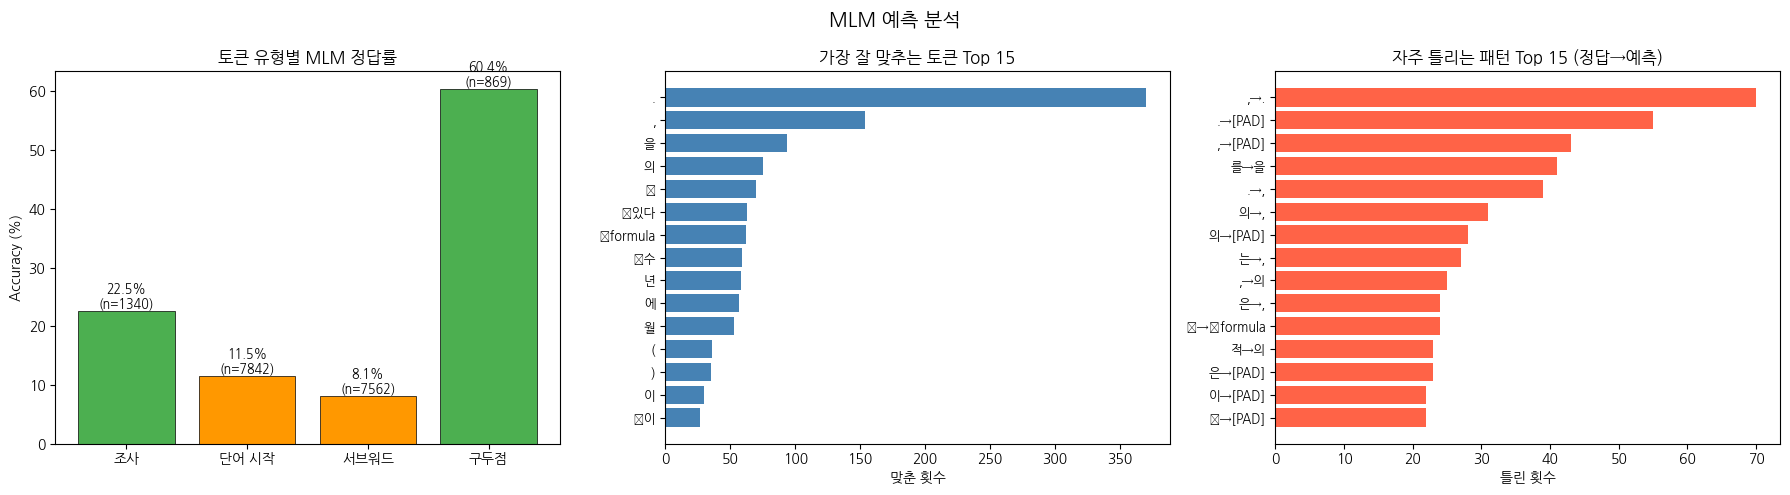

In [49]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

pre_train_model.eval()

correct_tokens = []  # 맞춘 토큰
wrong_tokens = []    # 틀린 (정답, 예측) 쌍
total_by_type = {}   # 토큰 유형별 정답률

n_samples = min(1000, len(train_dataset))

with torch.no_grad():
    for i in range(n_samples):
        tokens = pre_train_inputs[0][i].unsqueeze(0).to(device)
        segs = pre_train_inputs[1][i].unsqueeze(0).to(device)
        labels = pre_train_labels[1][i]
        
        _, logits_mlm = pre_train_model(tokens, segs)
        preds = logits_mlm.argmax(dim=-1)[0].cpu()
        
        mask_positions = (labels != 0).nonzero(as_tuple=True)[0]
        
        for pos in mask_positions:
            true_id = labels[pos].item()
            pred_id = preds[pos].item()
            true_token = vocab.id_to_piece(true_id)
            pred_token = vocab.id_to_piece(pred_id)
            
            # 토큰 유형 분류
            if true_token.startswith('▁'):
                token_type = '단어 시작'
            elif true_token in ['.', ',', '!', '?', '·']:
                token_type = '구두점'
            elif true_token in ['은', '는', '이', '가', '을', '를', '의', '에', '에서', '으로', '로']:
                token_type = '조사'
            else:
                token_type = '서브워드'
            
            if token_type not in total_by_type:
                total_by_type[token_type] = {'correct': 0, 'total': 0}
            total_by_type[token_type]['total'] += 1
            
            if true_id == pred_id:
                correct_tokens.append(true_token)
                total_by_type[token_type]['correct'] += 1
            else:
                wrong_tokens.append((true_token, pred_token))

# --- 시각화 1: 토큰 유형별 정답률 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

types = list(total_by_type.keys())
accs = [total_by_type[t]['correct'] / total_by_type[t]['total'] * 100 for t in types]
counts = [total_by_type[t]['total'] for t in types]

colors = ['#4CAF50' if a > 15 else '#FF9800' if a > 8 else '#F44336' for a in accs]
bars = axes[0].bar(types, accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc, cnt in zip(bars, accs, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.1f}%\n(n={cnt})', ha='center', fontsize=9)
axes[0].set_title('토큰 유형별 MLM 정답률')
axes[0].set_ylabel('Accuracy (%)')

# --- 시각화 2: 가장 많이 맞춘 토큰 Top 15 ---
from collections import Counter
correct_counts = Counter(correct_tokens).most_common(15)
if correct_counts:
    tokens_c, counts_c = zip(*correct_counts)
    axes[1].barh(range(len(tokens_c)), counts_c, color='steelblue')
    axes[1].set_yticks(range(len(tokens_c)))
    axes[1].set_yticklabels(tokens_c, fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set_title('가장 잘 맞추는 토큰 Top 15')
    axes[1].set_xlabel('맞춘 횟수')

# --- 시각화 3: 자주 틀리는 (정답→예측) 패턴 Top 15 ---
wrong_counts = Counter(wrong_tokens).most_common(15)
if wrong_counts:
    labels_w = [f'{t}→{p}' for (t, p), _ in wrong_counts]
    counts_w = [c for _, c in wrong_counts]
    axes[2].barh(range(len(labels_w)), counts_w, color='tomato')
    axes[2].set_yticks(range(len(labels_w)))
    axes[2].set_yticklabels(labels_w, fontsize=9)
    axes[2].invert_yaxis()
    axes[2].set_title('자주 틀리는 패턴 Top 15 (정답→예측)')
    axes[2].set_xlabel('틀린 횟수')

plt.suptitle('MLM 예측 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('work/viz_mlm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


#### 소회

- 구두점은 60%나 정답을 맞추고 있다. (출현 빈도 높고 패턴이 단순함)
- 단어/서브워드는 경우의 수가 8,000개나 되어 정답률이 매우 낮다.
- 자주 틀리는 패턴을 보면 모델이 확신이 없을 때 PAD(0번 토큰)로 예측하는 경우를 예상해볼 수 있다.

## 6. 모델 개선

### 6-1. 모델 초기화, New history 관리

In [51]:
# 모델은 새로 초기화해서 처음부터 다시 학습
pre_train_model_v2 = build_model_pre_train(config)
pre_train_model_v2.to(device)

# 이전 history는 보존하고 새 history 따로 관리
history_v2 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

### 6-2. MLM Loss 개선방안 - 마스크된 위치만 계산 + label smoothing

In [58]:
# 개선된 MLM Loss - 마스크된 위치만 계산 + label smoothing
def masked_mlm_loss(labels, logits):
    mask = (labels != 0)
    logits_masked = logits[mask]
    labels_masked = labels[mask]
    
    if labels_masked.numel() == 0:
        return torch.tensor(0.0, device=logits.device)
    
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
    return loss_fn(logits_masked, labels_masked)

print("완료")

완료


#### 마스크된 위치만 계산하는 이유

- 마스크된 위치만 계산하는 이유는 모델이 확신이 없을 때 [PAD]로 예측하는 경우의 수를 Loss값에 포함시키지 않기 위해서이다.

#### Label Smoothing을 하는 이유

- 모델이 특정 토큰(구두점, PAD)에만 과도하게 집중하는 현상을 완화하기 위해서이다.

### 6-3. 2차 학습 - 모델 초기화 및 학습 설정

In [ ]:
# 모델 새로 초기화
pre_train_model_v2 = build_model_pre_train(config)
pre_train_model_v2.to(device)

# 학습 설정
epochs_v2 = 10
batch_size = 64

train_steps_v2 = math.ceil(len(train_dataloader)) * epochs_v2
warmup_steps_v2 = max(100, train_steps_v2 // 5)  # 20%로 증가

optimizer_v2 = optim.Adam(pre_train_model_v2.parameters(), lr=1e-5)
learning_rate_scheduler_v2 = CosineSchedule(
    optimizer=optimizer_v2,
    train_steps=train_steps_v2,
    warmup_steps=warmup_steps_v2,
    max_lr=1e-4
)

loss_fn_nsp_v2 = nn.CrossEntropyLoss()

history_v2 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

print(f"train_steps: {train_steps_v2}, warmup_steps: {warmup_steps_v2}")

train_steps: 143470, warmup_steps: 28694


### 6-4. 2차 학습 루프

In [60]:
for epoch in range(epochs_v2):
    pre_train_model_v2.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs_v2}"):
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer_v2.zero_grad()

        # 순전파
        logits_nsp, logits_mlm = pre_train_model_v2(enc_tokens_batch, segments_batch)

        # label 타입 변환
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        # loss 계산
        loss_nsp = loss_fn_nsp_v2(logits_nsp, labels_nsp_batch)
        loss_mlm = masked_mlm_loss(labels_mlm_batch, logits_mlm)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # 역전파
        total_loss_batch.backward()
        optimizer_v2.step()
        learning_rate_scheduler_v2.step()  # 스케줄러 수정

        # accuracy 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = lm_acc(labels_mlm_batch, logits_mlm)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 에폭별 평균 기록
    history_v2['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history_v2['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history_v2['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history_v2['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs_v2} "
          f"- Loss: {total_loss / len(train_dataloader):.4f} "
          f"- NSP Loss: {history_v2['nsp_loss'][-1]:.4f} "
          f"- MLM Loss: {history_v2['mlm_loss'][-1]:.4f} "
          f"- NSP Acc: {history_v2['nsp_acc'][-1]:.4f} "
          f"- MLM Acc: {history_v2['mlm_acc'][-1]:.4f}")

    # 모델 저장
    torch.save(
        pre_train_model_v2.state_dict(),
        os.path.join(work_dir, f"bert_pre_train_v2_epoch_{epoch+1}.pt")
    )

Epoch 1/10: 100%|██████████| 14347/14347 [08:33<00:00, 27.93it/s]


Epoch 1/10 - Loss: 8.3107 - NSP Loss: 0.4612 - MLM Loss: 7.8495 - NSP Acc: 0.7210 - MLM Acc: 0.0472


Epoch 2/10: 100%|██████████| 14347/14347 [06:01<00:00, 39.65it/s]


Epoch 2/10 - Loss: 7.4590 - NSP Loss: 0.3789 - MLM Loss: 7.0801 - NSP Acc: 0.7617 - MLM Acc: 0.1052


Epoch 3/10: 100%|██████████| 14347/14347 [06:57<00:00, 34.39it/s]


...

Epoch 8/10 - Loss: 5.8545 - NSP Loss: 0.3527 - MLM Loss: 5.5017 - NSP Acc: 0.7753 - MLM Acc: 0.2296


Epoch 9/10: 100%|██████████| 14347/14347 [08:44<00:00, 27.34it/s]


Epoch 9/10 - Loss: 5.8326 - NSP Loss: 0.3508 - MLM Loss: 5.4818 - NSP Acc: 0.7773 - MLM Acc: 0.2316


Epoch 10/10: 100%|██████████| 14347/14347 [05:32<00:00, 43.19it/s]

Epoch 10/10 - Loss: 5.8246 - NSP Loss: 0.3502 - MLM Loss: 5.4744 - NSP Acc: 0.7779 - MLM Acc: 0.2323


### 6-5. 1차 학습 / 2차 학습 비교

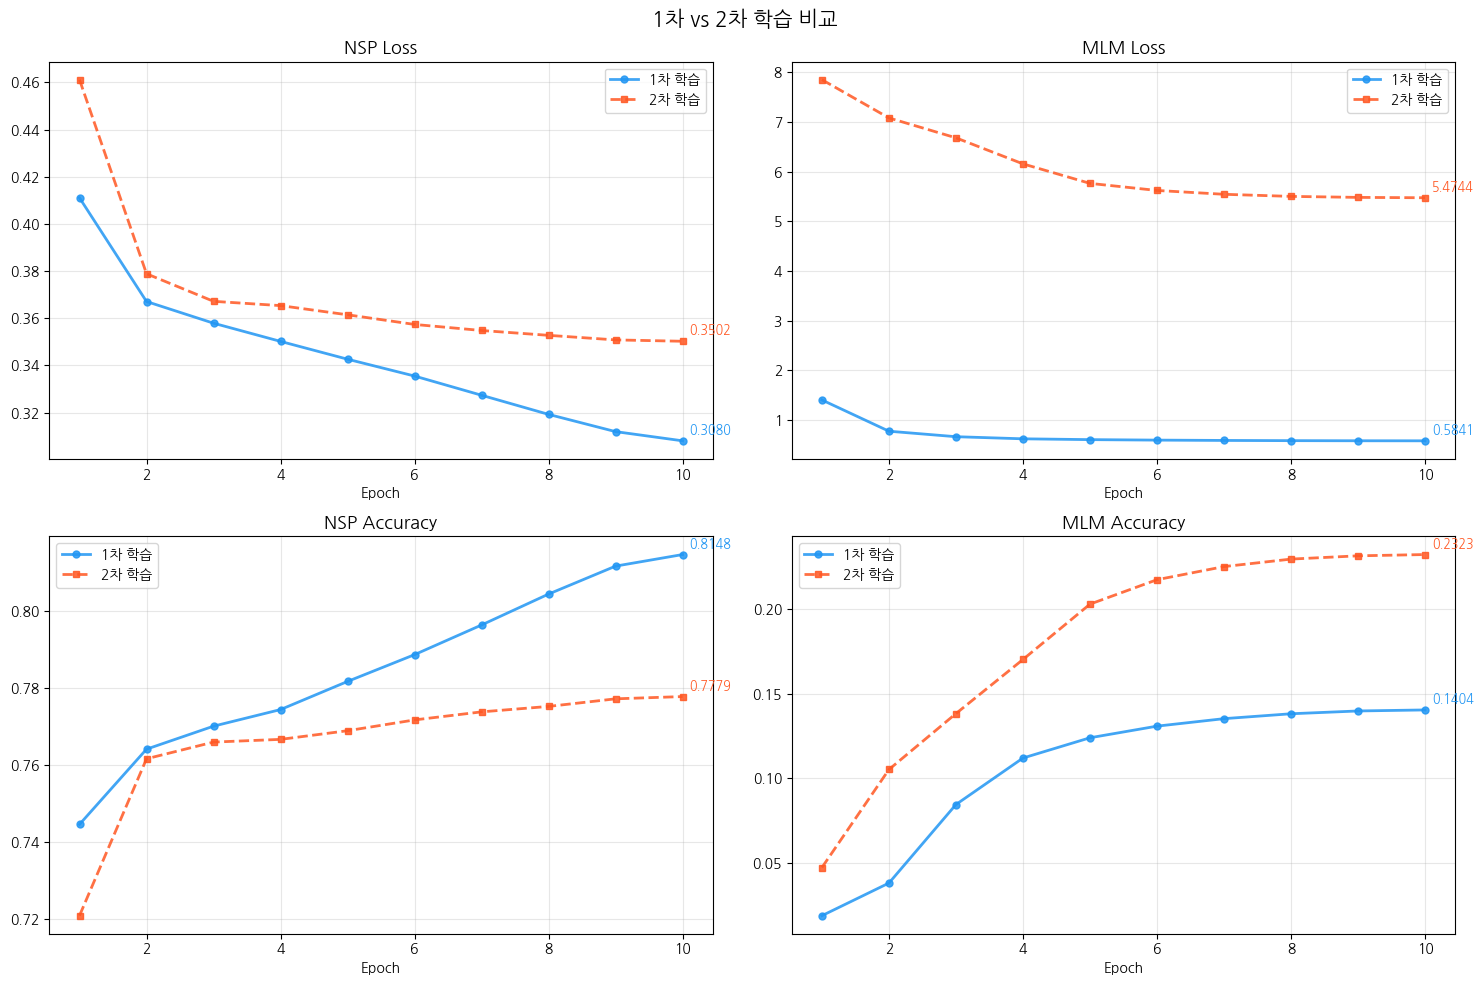

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [
    ('nsp_loss', 'NSP Loss',     axes[0, 0]),
    ('mlm_loss', 'MLM Loss',     axes[0, 1]),
    ('nsp_acc',  'NSP Accuracy', axes[1, 0]),
    ('mlm_acc',  'MLM Accuracy', axes[1, 1]),
]

runs = {
    '1차 학습': (history,    '#2196F3', 'o', '-'),
    '2차 학습': (history_v2, '#FF5722', 's', '--'),
}

for key, title, ax in metrics:
    for label, (hist, color, marker, linestyle) in runs.items():
        epochs = range(1, len(hist[key]) + 1)
        ax.plot(epochs, hist[key],
                color=color, marker=marker, linestyle=linestyle,
                ms=5, linewidth=2, label=label, alpha=0.85)

        # 최종값 표시
        ax.annotate(f'{hist[key][-1]:.4f}',
                    xy=(len(hist[key]), hist[key][-1]),
                    xytext=(5, 5), textcoords='offset points',
                    color=color, fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('1차 vs 2차 학습 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('work/viz_compare_v1_v2.png', dpi=150, bbox_inches='tight')
plt.show()

#### 소회

- 1차의 NSP Accuracy는 굉장히 높은 수준으로 나타났다.
- 2차의 MLM Accuracy가 1차의 MLM Accuracy보다 높게 나타났다.
- 1차 LR + 2차 loss 함수 조합으로 3차 학습을 하면 NSP와 MLM을 동시에 잡을 가능성이 높을 것 같다. (가설)
- 마지막으로 1차 LR + 2차 loss 함수 조합으로 3차 학습 (Epoch 20회) 진행해보려 한다.

## 7. 3차 학습 (1차 LR + 2차 loss 함수)

### 7-1. 모델초기화 및 학습 설정

In [64]:
# 모델 초기화
pre_train_model_v3 = build_model_pre_train(config).to(device)

# 학습 설정
epochs_v3 = 20
train_steps_v3 = math.ceil(len(train_dataloader)) * epochs_v3
warmup_steps_v3 = max(100, train_steps_v3 // 10)  # 1차와 동일 (10%)

# optimizer 및 스케줄러 설정
optimizer_v3 = optim.Adam(pre_train_model_v3.parameters(), lr=1e-4)
learning_rate_scheduler_v3 = CosineSchedule(
    optimizer=optimizer_v3,
    train_steps=train_steps_v3,
    warmup_steps=warmup_steps_v3,
    max_lr=5e-4  # 1차와 동일
)

# loss 함수 설정
loss_fn_nsp_v3 = nn.CrossEntropyLoss()

# 학습 기록
history_v3 = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc':  [],
    'mlm_acc':  []
}

print(f"train_steps: {train_steps_v3}, warmup_steps: {warmup_steps_v3}")


train_steps: 286940, warmup_steps: 28694


### 7-2. 학습 루프

In [66]:
for epoch in range(epochs_v3):
    pre_train_model_v3.train()
    total_loss     = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc  = 0
    total_mlm_acc  = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs_v3}"):
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer_v3.zero_grad()

        # 순전파
        logits_nsp, logits_mlm = pre_train_model_v3(enc_tokens_batch, segments_batch)

        # label 타입 변환
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        # loss 계산
        loss_nsp = loss_fn_nsp_v3(logits_nsp, labels_nsp_batch)
        loss_mlm = masked_mlm_loss(labels_mlm_batch, logits_mlm)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss     += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # 역전파
        total_loss_batch.backward()
        optimizer_v3.step()
        learning_rate_scheduler_v3.step()

        # accuracy 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = lm_acc(labels_mlm_batch, logits_mlm)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 에폭별 평균 기록
    history_v3['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history_v3['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history_v3['nsp_acc'].append(total_nsp_acc  / len(train_dataloader))
    history_v3['mlm_acc'].append(total_mlm_acc  / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs_v3} "
          f"- Loss: {total_loss / len(train_dataloader):.4f} "
          f"- NSP Loss: {history_v3['nsp_loss'][-1]:.4f} "
          f"- MLM Loss: {history_v3['mlm_loss'][-1]:.4f} "
          f"- NSP Acc: {history_v3['nsp_acc'][-1]:.4f} "
          f"- MLM Acc: {history_v3['mlm_acc'][-1]:.4f}")

    # 모델 저장
    torch.save(
        pre_train_model_v3.state_dict(),
        os.path.join(work_dir, f"bert_pre_train_v3_epoch_{epoch+1}.pt")
    )


Epoch 1/20: 100%|██████████| 14347/14347 [08:49<00:00, 27.12it/s]


Epoch 1/20 - Loss: 7.8158 - NSP Loss: 0.4187 - MLM Loss: 7.3971 - NSP Acc: 0.7422 - MLM Acc: 0.0816


Epoch 2/20: 100%|██████████| 14347/14347 [08:44<00:00, 27.38it/s]


Epoch 2/20 - Loss: 6.4414 - NSP Loss: 0.3724 - MLM Loss: 6.0690 - NSP Acc: 0.7607 - MLM Acc: 0.1814


Epoch 3/20: 100%|██████████| 14347/14347 [09:18<00:00, 25.70it/s]


...

Epoch 18/20 - Loss: 5.3244 - NSP Loss: 0.3271 - MLM Loss: 4.9973 - NSP Acc: 0.7940 - MLM Acc: 0.2929


Epoch 19/20: 100%|██████████| 14347/14347 [06:45<00:00, 35.37it/s]


Epoch 19/20 - Loss: 5.3198 - NSP Loss: 0.3262 - MLM Loss: 4.9936 - NSP Acc: 0.7951 - MLM Acc: 0.2933


Epoch 20/20: 100%|██████████| 14347/14347 [06:45<00:00, 35.37it/s]

Epoch 20/20 - Loss: 5.3176 - NSP Loss: 0.3258 - MLM Loss: 4.9918 - NSP Acc: 0.7952 - MLM Acc: 0.2936


### 6-3. 3차 학습 결과 시각화

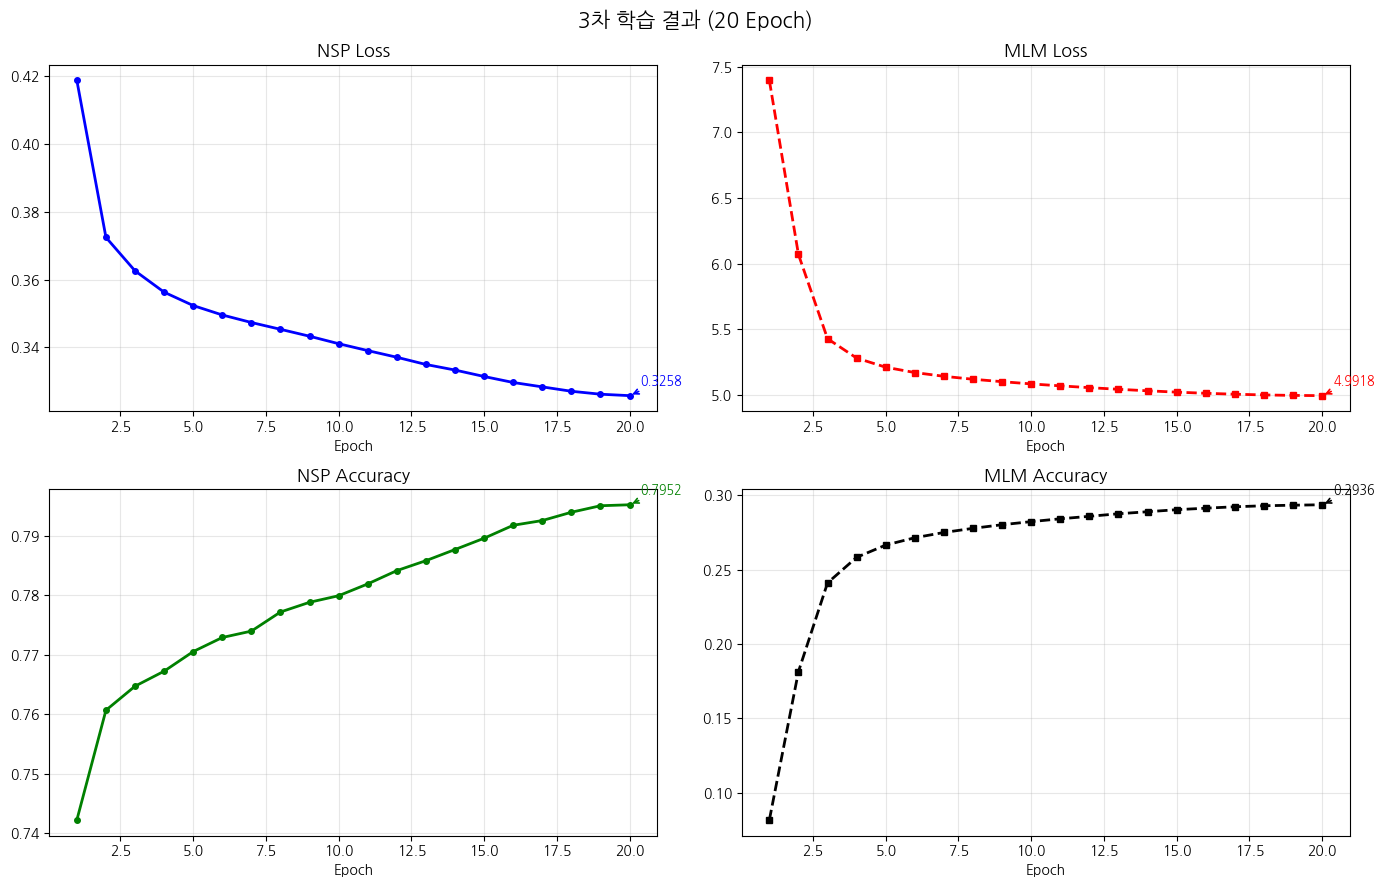

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

configs = [
    ('nsp_loss', 'NSP Loss',     'blue',  'o', '-'),
    ('mlm_loss', 'MLM Loss',     'red',   's', '--'),
    ('nsp_acc',  'NSP Accuracy', 'green', 'o', '-'),
    ('mlm_acc',  'MLM Accuracy', 'black', 's', '--'),
]

for (key, title, color, marker, linestyle), ax in zip(configs, axes.flatten()):
    epochs = range(1, len(history_v3[key]) + 1)
    ax.plot(epochs, history_v3[key],
            color=color, marker=marker, linestyle=linestyle,
            ms=4, linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

    # 최솟값/최댓값 표시
    vals = history_v3[key]
    best_idx = vals.index(min(vals)) if 'loss' in key else vals.index(max(vals))
    best_val = vals[best_idx]
    ax.annotate(f'{best_val:.4f}',
                xy=(best_idx + 1, best_val),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

plt.suptitle('3차 학습 결과 (20 Epoch)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('work/viz_history_v3.png', dpi=150, bbox_inches='tight')
plt.show()

#### 소회

- NSP Accuracy는 아직 수렴하지 않고 있다. (꽤 높은 정확도)
- MLM Accuracy는 수렴하고 있다. (생각보다는 낮은 정확도)
- 그래도 1차, 2차를 합쳐보니 꽤 안정적인 결과를 얻은 것 같다.

### 6-4. 1차 모델 테스트

#### MLM 테스트 - 마스킹된 토큰 예측

In [70]:
def test_mlm(model, vocab, sentence, mask_targets, device, top_k=5):
    """
    sentence   : 입력 문장 (str)
    mask_targets: 마스킹할 단어 리스트 (list of str)
    """
    model.eval()
    mask_id  = vocab.piece_to_id('[MASK]')
    cls_id   = vocab.piece_to_id('[CLS]')
    sep_id   = vocab.piece_to_id('[SEP]')
    n_seq    = 128

    # 토크나이징
    tokens = vocab.encode_as_pieces(sentence)
    token_ids = [cls_id] + [vocab.piece_to_id(t) for t in tokens] + [sep_id]

    # 마스킹
    masked_positions = {}
    for target in mask_targets:
        target_pieces = vocab.encode_as_pieces(target)
        for i, piece in enumerate(token_ids):
            if vocab.id_to_piece(piece) == target_pieces[0]:
                masked_positions[i] = piece  # 원래 id 저장
                token_ids[i] = mask_id

    # 패딩
    pad_len = n_seq - len(token_ids)
    token_ids = token_ids + [0] * pad_len
    segments  = [0] * n_seq

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    seg_ids   = torch.tensor([segments],  dtype=torch.long).to(device)

    with torch.no_grad():
        _, logits_mlm = model(input_ids, seg_ids)

    print(f"\n📝 입력 문장: {sentence}")
    print("=" * 55)

    for pos, true_id in masked_positions.items():
        true_token = vocab.id_to_piece(true_id)
        top_ids    = logits_mlm[0, pos].topk(top_k).indices.tolist()
        top_tokens = [vocab.id_to_piece(i) for i in top_ids]
        top_scores = logits_mlm[0, pos].topk(top_k).values.tolist()

        correct = '✅' if true_token in top_tokens else '❌'
        print(f"\n[MASK] 정답: {true_token} {correct}")
        print(f"  Top-{top_k} 예측:")
        for rank, (tok, score) in enumerate(zip(top_tokens, top_scores), 1):
            marker = '👉' if tok == true_token else '  '
            print(f"  {marker} {rank}. {tok:15s} (score: {score:.4f})")


# 테스트 실행
test_sentences = [
    ("한국의 수도는 서울이다.",          ["서울"]),
    ("그는 매일 아침 커피를 마신다.",     ["커피"]),
    ("딥러닝은 인공지능의 한 분야이다.",  ["인공지능"]),
    ("봄에는 벚꽃이 아름답게 핀다.",     ["벚꽃"]),
]

for sentence, targets in test_sentences:
    test_mlm(pre_train_model_v3, vocab, sentence, targets, device)


📝 입력 문장: 한국의 수도는 서울이다.

[MASK] 정답: ▁서울 ❌
  Top-5 예측:
     1. ▁다음을            (score: 9.7198)
     2. ▁대한민국의          (score: 9.1661)
     3. ▁다음             (score: 8.7309)
     4. ▁다음과            (score: 7.4403)
     5. ▁일본의            (score: 6.6404)

📝 입력 문장: 그는 매일 아침 커피를 마신다.

[MASK] 정답: ▁커 ❌
  Top-5 예측:
     1. ▁때              (score: 7.3214)
     2. ▁다음             (score: 7.2203)
     3. ▁후              (score: 6.4539)
     4. ▁첫              (score: 6.3985)
     5. ▁동안             (score: 6.3589)

📝 입력 문장: 딥러닝은 인공지능의 한 분야이다.

[MASK] 정답: ▁인 ❌
  Top-5 예측:
     1. ▁대한민국의          (score: 10.2667)
     2. ▁미국의            (score: 8.1837)
     3. ▁대한민국           (score: 7.5352)
     4. ▁컴퓨터            (score: 7.1302)
     5. ▁한국             (score: 6.8139)

📝 입력 문장: 봄에는 벚꽃이 아름답게 핀다.

[MASK] 정답: ▁ ❌
  Top-5 예측:
     1. ▁봄              (score: 7.6844)
     2. 에는              (score: 7.1494)
     3. ▁꽃              (score: 6.6150)
     4. ▁이름이            (score: 6.5694)
     5. ▁잎     

#### 소회

- 관찰된 패턴 : 고빈도 일반 단어 위주 (다음을, 다음, 때, 후, 첫 등)
- 정답 토큰 : 서울, 커(피), 인공(지능) 등 내용어 위주
- 틀린 이유
    - 빈도 편향 (모델이 의미를 이해하는 게 아니라 학습 데이터에서 자주 등장한 토큰을 예측하는 경향)
    - 내용어는 문맥없이 예측하기 매우 어려운 토큰임

#### NSP 테스트 - 두 문장의 연속성 예측

In [71]:
def test_nsp(model, vocab, sent_a, sent_b, device):
    """
    sent_a: 첫 번째 문장
    sent_b: 두 번째 문장 (IsNext or NotNext)
    """
    model.eval()
    cls_id = vocab.piece_to_id('[CLS]')
    sep_id = vocab.piece_to_id('[SEP]')
    n_seq  = 128

    tokens_a = [cls_id] + [vocab.piece_to_id(p)
                            for p in vocab.encode_as_pieces(sent_a)] + [sep_id]
    tokens_b = [vocab.piece_to_id(p)
                for p in vocab.encode_as_pieces(sent_b)] + [sep_id]

    token_ids = tokens_a + tokens_b
    segments  = [0] * len(tokens_a) + [1] * len(tokens_b)

    # 패딩
    pad_len   = n_seq - len(token_ids)
    token_ids = token_ids[:n_seq] + [0] * max(0, pad_len)
    segments  = segments[:n_seq]  + [0] * max(0, pad_len)

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    seg_ids   = torch.tensor([segments],  dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, _ = model(input_ids, seg_ids)

    probs      = torch.softmax(logits_nsp, dim=-1)[0]
    is_next    = probs[1].item()
    not_next   = probs[0].item()
    prediction = 'IsNext ✅' if is_next > not_next else 'NotNext ❌'

    print(f"\n문장 A: {sent_a}")
    print(f"문장 B: {sent_b}")
    print(f"예측:   {prediction}")
    print(f"  IsNext  확률: {is_next:.4f}")
    print(f"  NotNext 확률: {not_next:.4f}")
    print("-" * 55)


# IsNext 쌍 (연속된 문장)
print("▶ IsNext 테스트 (연속된 문장)")
test_nsp(pre_train_model_v3, vocab,
         "서울은 대한민국의 수도이다.",
         "많은 사람들이 서울에서 생활하고 있다.", device)

test_nsp(pre_train_model_v3, vocab,
         "그는 아침 일찍 일어났다.",
         "그리고 바로 운동을 시작했다.", device)

# NotNext 쌍 (관련 없는 문장)
print("\n▶ NotNext 테스트 (관련 없는 문장)")
test_nsp(pre_train_model_v3, vocab,
         "서울은 대한민국의 수도이다.",
         "축구는 전 세계에서 인기 있는 스포츠이다.", device)

test_nsp(pre_train_model_v3, vocab,
         "오늘 날씨가 매우 맑다.",
         "경제 성장률이 올해 크게 하락했다.", device)


▶ IsNext 테스트 (연속된 문장)

문장 A: 서울은 대한민국의 수도이다.
문장 B: 많은 사람들이 서울에서 생활하고 있다.
예측:   IsNext ✅
  IsNext  확률: 0.8381
  NotNext 확률: 0.1619
-------------------------------------------------------

문장 A: 그는 아침 일찍 일어났다.
문장 B: 그리고 바로 운동을 시작했다.
예측:   NotNext ❌
  IsNext  확률: 0.3039
  NotNext 확률: 0.6961
-------------------------------------------------------

▶ NotNext 테스트 (관련 없는 문장)

문장 A: 서울은 대한민국의 수도이다.
문장 B: 축구는 전 세계에서 인기 있는 스포츠이다.
예측:   IsNext ✅
  IsNext  확률: 0.5940
  NotNext 확률: 0.4060
-------------------------------------------------------

문장 A: 오늘 날씨가 매우 맑다.
문장 B: 경제 성장률이 올해 크게 하락했다.
예측:   NotNext ❌
  IsNext  확률: 0.2456
  NotNext 확률: 0.7544
-------------------------------------------------------


#### 소회

- 학습 정확도(약 81%)와 차이가 나는 이유
    - '그리고'가 있는데도 NotNext로 예측하였음. (모델이 접속사 IsNext 신호로 학습 못 함)
    - 관련 없는 문장을 IsNext로 예측하였음. (모델이 내용보다 문체/스타일 패턴으로 IsNext 판단함)
- 테스트 문장(샘플)이 너무 적은 것 같아 테스트 문장 10개로 늘려 2차 테스트 진행해보려 한다.

### 6-5. 2차 모델 테스트

#### MLM 테스트

In [74]:
mlm_test_cases = [
    ("한국의 수도는 서울이다.",                  ["서울"]),
    ("세계에서 가장 높은 산은 에베레스트이다.",    ["에베레스트"]),
    ("지구는 태양 주위를 공전한다.",              ["태양"]),
    ("그는 매일 아침 커피를 마신다.",             ["커피"]),
    ("학생들은 도서관에서 공부를 한다.",           ["도서관"]),
    ("봄에는 벚꽃이 아름답게 핀다.",              ["벚꽃"]),
    ("딥러닝은 인공지능의 한 분야이다.",           ["인공지능"]),
    ("스마트폰은 현대인의 필수품이 되었다.",        ["스마트폰"]),
    ("조선은 한반도에 세워진 왕조이다.",           ["조선"]),
    ("축구는 전 세계에서 인기 있는 스포츠이다.",   ["축구"]),
]

mlm_results = []

for sentence, targets in mlm_test_cases:
    pre_train_model_v3.eval()
    mask_id = vocab.piece_to_id('[MASK]')
    cls_id  = vocab.piece_to_id('[CLS]')
    sep_id  = vocab.piece_to_id('[SEP]')
    n_seq   = 128

    tokens    = vocab.encode_as_pieces(sentence)
    token_ids = [cls_id] + [vocab.piece_to_id(t) for t in tokens] + [sep_id]

    masked_positions = {}
    for target in targets:
        target_pieces = vocab.encode_as_pieces(target)
        for i, piece in enumerate(token_ids):
            if vocab.id_to_piece(piece) == target_pieces[0]:
                masked_positions[i] = piece
                token_ids[i] = mask_id
                break

    pad_len   = n_seq - len(token_ids)
    token_ids = token_ids + [0] * pad_len
    segments  = [0] * n_seq

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    seg_ids   = torch.tensor([segments],  dtype=torch.long).to(device)

    with torch.no_grad():
        _, logits_mlm = pre_train_model_v3(input_ids, seg_ids)

    for pos, true_id in masked_positions.items():
        true_token  = vocab.id_to_piece(true_id)
        top5_ids    = logits_mlm[0, pos].topk(5).indices.tolist()
        top5_tokens = [vocab.id_to_piece(i) for i in top5_ids]
        is_correct  = true_token in top5_tokens

        mlm_results.append({
            'sentence': sentence,
            'answer':   true_token,
            'top5':     top5_tokens,
            'correct':  is_correct,
        })

# 결과 요약 출력
print("=" * 65)
print(f"{'문장':<35} {'정답':<12} {'Top5':<6} {'Top1 예측'}")
print("=" * 65)
for r in mlm_results:
    top1    = r['top5'][0]
    correct = '✅' if r['correct'] else '❌'
    print(f"{r['sentence'][:33]:<35} {r['answer']:<12} {correct}      {top1}")

total   = len(mlm_results)
correct = sum(r['correct'] for r in mlm_results)
print("=" * 65)
print(f"Top-5 정확도: {correct}/{total}  ({correct/total*100:.1f}%)")
print("=" * 65)


문장                                  정답           Top5   Top1 예측
한국의 수도는 서울이다.                       ▁서울          ❌      ▁다음을
세계에서 가장 높은 산은 에베레스트이다.              ▁에           ❌      ▁독일의
지구는 태양 주위를 공전한다.                    ▁태양          ✅      ▁지구
그는 매일 아침 커피를 마신다.                   ▁커           ❌      ▁때
학생들은 도서관에서 공부를 한다.                  ▁도           ❌      ▁학생
봄에는 벚꽃이 아름답게 핀다.                    ▁            ❌      ▁봄
딥러닝은 인공지능의 한 분야이다.                  ▁인           ❌      ▁대한민국의
스마트폰은 현대인의 필수품이 되었다.                ▁스           ❌      ▁현대
조선은 한반도에 세워진 왕조이다.                  ▁조선          ❌      ▁다음
축구는 전 세계에서 인기 있는 스포츠이다.             ▁축구          ❌      ▁다음
Top-5 정확도: 1/10  (10.0%)


#### 소회

- 동일하게 고빈도 단어 위주 반복 예측
- 유일한 정답 : '주위를 공전한다'는 강한 문맥 -> Top-5 안에 포함
- 주목할 실패 케이스 : '에베레스트'를 '에', '베레스트'로 분절 (마스킹 자체가 의미 없는 조각을 대상으로 함)

#### NSP 테스트

In [75]:
nsp_test_cases = [
    ("서울은 대한민국의 수도이다.",
     "많은 사람들이 서울에서 생활하고 있다.",           "IsNext"),
    ("그는 아침 일찍 일어났다.",
     "그리고 바로 운동을 시작했다.",                    "IsNext"),
    ("오늘 비가 많이 내렸다.",
     "우산을 가져오지 않은 사람들은 옷이 젖었다.",       "IsNext"),
    ("한국은 사계절이 뚜렷한 나라이다.",
     "봄에는 꽃이 피고 겨울에는 눈이 내린다.",          "IsNext"),
    ("그 영화는 전 세계적으로 큰 인기를 끌었다.",
     "개봉 첫 주에만 수백만 명의 관객이 몰렸다.",        "IsNext"),
    ("서울은 대한민국의 수도이다.",
     "축구는 전 세계에서 인기 있는 스포츠이다.",         "NotNext"),
    ("오늘 날씨가 매우 맑다.",
     "경제 성장률이 올해 크게 하락했다.",               "NotNext"),
    ("그는 매일 아침 커피를 마신다.",
     "우주는 약 138억 년 전에 탄생했다.",               "NotNext"),
    ("도서관에는 다양한 책이 있다.",
     "태권도는 한국의 전통 무술이다.",                  "NotNext"),
    ("봄에는 벚꽃이 아름답게 핀다.",
     "컴퓨터 프로그래밍은 논리적 사고를 필요로 한다.",   "NotNext"),
]

nsp_results = []

for sent_a, sent_b, true_label in nsp_test_cases:
    pre_train_model_v3.eval()
    cls_id = vocab.piece_to_id('[CLS]')
    sep_id = vocab.piece_to_id('[SEP]')
    n_seq  = 128

    tokens_a  = [cls_id] + [vocab.piece_to_id(p)
                 for p in vocab.encode_as_pieces(sent_a)] + [sep_id]
    tokens_b  = [vocab.piece_to_id(p)
                 for p in vocab.encode_as_pieces(sent_b)] + [sep_id]
    token_ids = (tokens_a + tokens_b)[:n_seq]
    segments  = ([0] * len(tokens_a) + [1] * len(tokens_b))[:n_seq]
    pad_len   = n_seq - len(token_ids)
    token_ids += [0] * pad_len
    segments  += [0] * pad_len

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    seg_ids   = torch.tensor([segments],  dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, _ = pre_train_model_v3(input_ids, seg_ids)

    probs      = torch.softmax(logits_nsp, dim=-1)[0]
    is_next_p  = probs[1].item()
    not_next_p = probs[0].item()
    pred_label = "IsNext" if is_next_p > not_next_p else "NotNext"
    is_correct = (pred_label == true_label)

    nsp_results.append({
        'sent_a':     sent_a,
        'sent_b':     sent_b,
        'true_label': true_label,
        'pred_label': pred_label,
        'is_next_p':  is_next_p,
        'not_next_p': not_next_p,
        'correct':    is_correct,
    })

# 결과 요약 출력
print("=" * 75)
print(f"{'문장 A':<28} {'문장 B':<28} {'정답':<9} {'예측':<9} {'결과'}")
print("=" * 75)
for r in nsp_results:
    correct = '✅' if r['correct'] else '❌'
    print(f"{r['sent_a'][:26]:<28} {r['sent_b'][:26]:<28} "
          f"{r['true_label']:<9} {r['pred_label']:<9} {correct}")

total   = len(nsp_results)
correct = sum(r['correct'] for r in nsp_results)
is_next_correct  = sum(r['correct'] for r in nsp_results if r['true_label'] == 'IsNext')
not_next_correct = sum(r['correct'] for r in nsp_results if r['true_label'] == 'NotNext')

print("=" * 75)
print(f"전체 정확도  : {correct}/{total} ({correct/total*100:.1f}%)")
print(f"IsNext  정확도: {is_next_correct}/5  ({is_next_correct/5*100:.1f}%)")
print(f"NotNext 정확도: {not_next_correct}/5  ({not_next_correct/5*100:.1f}%)")
print("=" * 75)


문장 A                         문장 B                         정답        예측        결과
서울은 대한민국의 수도이다.              많은 사람들이 서울에서 생활하고 있다.        IsNext    IsNext    ✅
그는 아침 일찍 일어났다.               그리고 바로 운동을 시작했다.             IsNext    NotNext   ❌
오늘 비가 많이 내렸다.                우산을 가져오지 않은 사람들은 옷이 젖었다.     IsNext    NotNext   ❌
한국은 사계절이 뚜렷한 나라이다.           봄에는 꽃이 피고 겨울에는 눈이 내린다.       IsNext    NotNext   ❌
그 영화는 전 세계적으로 큰 인기를 끌었다.     개봉 첫 주에만 수백만 명의 관객이 몰렸다.     IsNext    IsNext    ✅
서울은 대한민국의 수도이다.              축구는 전 세계에서 인기 있는 스포츠이다.      NotNext   IsNext    ❌
오늘 날씨가 매우 맑다.                경제 성장률이 올해 크게 하락했다.          NotNext   NotNext   ✅
그는 매일 아침 커피를 마신다.            우주는 약 138억 년 전에 탄생했다.        NotNext   NotNext   ✅
도서관에는 다양한 책이 있다.             태권도는 한국의 전통 무술이다.            NotNext   NotNext   ✅
봄에는 벚꽃이 아름답게 핀다.             컴퓨터 프로그래밍은 논리적 사고를 필요로 한다.   NotNext   IsNext    ❌
전체 정확도  : 5/10 (50.0%)
IsNext  정확도: 2/5  (40.0%)
NotNext 정확도: 3/5  (60.0%)


#### 소회

- NSP IsNext 40% : 짧은 인과문 취약 (의미 이해 부족해보임)
- NSP NoteNext 60% : 명확히 다른 주제는 구별 (극단적 차이는 인식 가능해보임)